# 1. Разведочный анализ данных

Состав набора, форматы выгрузки, длительности и поведение, возраст, качество сигнала, спектры. Сравнения групп здесь описательные: признаки модели выбраны по литературе (раздел 1.10), а не по этим графикам.

Разделы 1.1–1.10 — исходный выпуск (166 испытуемых), 1.11 — партии 24.09 (23 нормы 65+ и 40 молодых норм).

In [1]:
import sys
import warnings
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "results" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import config, dataset, diagnostics, features, preprocessing, viz

warnings.filterwarnings("ignore", message="All-NaN slice encountered")
warnings.filterwarnings("ignore", message="Mean of empty slice")
viz.apply_style()
pd.set_option("display.precision", 2)
COHORTS = list(config.GROUPS)
cfg = preprocessing.PreprocessingConfig()

## 1.1 Состав и целостность

Побитовые копии записей объединяют ID в независимые группы `split_group` — единицу всех разбиений train/test.

In [2]:
registry_all, links, subjects_all = dataset.scan_dataset(config.DATA_DIR)
original = subjects_all.index[~subjects_all["holdout"] & subjects_all["has_task_files"]]
registry = registry_all[registry_all["subject_key"].isin(original)].copy()
subjects = subjects_all.loc[original].copy()
ok = registry[registry["status"] == "ok"]

summary = registry.groupby("group").agg(
    испытуемых=("subject_id", "nunique"),
    файлов=("relpath", "size"),
    непустых=("status", lambda s: (s == "ok").sum()),
).reindex(COHORTS)
summary["независимых групп"] = subjects.groupby("group")["split_group"].nunique().reindex(COHORTS)
summary

,испытуемых,файлов,непустых,независимых групп
group,,,,
Норма,67,402,402,67
ПТСР,25,150,150,24
Соматоформные,74,444,439,67


In [3]:
print("Пустые файлы:", registry.loc[registry["status"] != "ok", "relpath"].tolist())
print("Заголовок n_records = -1:", int((ok["n_records_header"] == -1).sum()), "файлов, читаются по размеру файла")
same = links["subject_a"] == links["subject_b"]
print(f"Связей по совпадающему содержимому: {len(links)} (между разными ID: {(~same).sum()}, внутри ID: {same.sum()})")
links[["relpath_a", "relpath_b"]]

Пустые файлы: ['Соматоформные/XCFU5/T-1.edf', 'Соматоформные/XCFU5/T-2.edf', 'Соматоформные/XCFU5/T-3.edf', 'Соматоформные/XCFU5/T-4.edf', 'Соматоформные/XCFU5/T-5.edf']
Заголовок n_records = -1: 9 файлов, читаются по размеру файла
Связей по совпадающему содержимому: 27 (между разными ID: 22, внутри ID: 5)


,relpath_a,relpath_b
0,ПТСР/DFGH/T-П.edf,ПТСР/WSXD/T-1.edf
1,Соматоформные/DFGH8/T-2.edf,Соматоформные/DFGH8/T-3.edf
2,Соматоформные/DIKL0/T-1.edf,Соматоформные/GHRD3/T-П.edf
3,Соматоформные/DIKL0/T-2.edf,Соматоформные/GHRD3/T-1.edf
4,Соматоформные/DIKL0/T-3.edf,Соматоформные/GHRD3/T-2.edf
5,Соматоформные/DIKL0/T-4.edf,Соматоформные/GHRD3/T-3.edf
6,Соматоформные/KGBT5/T-4.edf,Соматоформные/KGBT5/T-5.edf
7,Соматоформные/KRTM8/T-5.edf,Соматоформные/PYVB0/T-5.edf
8,Соматоформные/LDPR3/T-3.edf,Соматоформные/ZILO6/T-4.edf
9,Соматоформные/LDPR3/T-4.edf,Соматоформные/ZILO6/T-5.edf


Часть копий встречается и как покой, и как проба (`condition_conflict`): условие записи неизвестно, и такие файлы не используются для признаков своего условия.

In [4]:
registry.loc[registry["condition_conflict"], ["relpath", "condition", "duplicate_set"]].sort_values("duplicate_set")

,relpath,condition,duplicate_set
792,ПТСР/DFGH/T-П.edf,rest,797
919,ПТСР/WSXD/T-1.edf,task,797
985,Соматоформные/DIKL0/T-1.edf,task,982
1044,Соматоформные/GHRD3/T-П.edf,rest,982
1103,Соматоформные/LDPR3/T-5.edf,task,1095
1350,Соматоформные/ZILO6/T-П.edf,rest,1095
1260,Соматоформные/TMVN4/T-П.edf,rest,1230
1241,Соматоформные/SIGO3/T-5.edf,task,1230
1265,Соматоформные/TMVN4/T-5.edf,task,1230
1326,Соматоформные/XYKT7/T-П.edf,rest,1305


Формат B дополняет конец записи нулями (`edge_constant_s`). Без обработки это дало бы ступеньку в последнем окне почти у всех ПТСР; предобработка обрезает такие края.

In [5]:
ok.assign(padded=ok["edge_constant_s"] >= 0.1).groupby(["group", "export_family"]).agg(
    файлов=("relpath", "size"), с_застывшим_краем=("padded", "sum"), медиана_с=("edge_constant_s", "median"),
    максимум_с=("edge_constant_s", "max"), внутри_записи_с=("interior_constant_s", "max"))

файлов  с_застывшим_краем  медиана_с  максимум_с  \
group         export_family                                                     
Норма         A                 120                  0       0.00        0.00   
              B                  12                 12       0.69        0.89   
              C                 270                  0       0.00        0.00   
ПТСР          B                 150                138       0.52        0.98   
Соматоформные A                 439                  0       0.00        0.00   

                             внутри_записи_с  
group         export_family                   
Норма         A                          0.0  
              B                          0.0  
              C                          0.0  
ПТСР          B                          0.0  
Соматоформные A                          0.0

## 1.2 Форматы выгрузки

Шаг квантования `Δ = (P_max − P_min)/(D_max − D_min)` — по каждому файлу. Формат в модель не подаётся: по нему проверяется, не различает ли модель способ экспорта вместо физиологии.

In [6]:
family = ok.groupby("subject_key")["export_family"].agg(lambda s: "".join(sorted(set(s))))
subjects["export_family"] = family.reindex(subjects.index)
fam_table = pd.crosstab(subjects["group"], subjects["export_family"]).reindex(COHORTS)
fam_table.columns = [f"формат {c}" for c in fam_table.columns]
fam_table

,формат A,формат B,формат C
group,,,
Норма,20,2,45
ПТСР,0,25,0
Соматоформные,74,0,0


In [7]:
(ok.groupby("export_family")
   .agg(шаг_мкВ_мин=("quant_step_uv", "min"), шаг_мкВ_макс=("quant_step_uv", "max"),
        диапазон_макс_мкВ=("physical_max", "max"), частоты_Гц=("sfreq", lambda s: sorted(s.unique())),
        доля_BS50=("notch_50", "mean"), файлов=("relpath", "size")))

,шаг_мкВ_мин,шаг_мкВ_макс,диапазон_макс_мкВ,частоты_Гц,доля_BS50,файлов
export_family,,,,,,
A,1.00e+00,1.00,32767.0,[125.0],1.0,559
B,6.10e-02,0.06,2000.0,[125.0],1.0,162
C,2.70e-03,0.02,871.0,"[123.0, 124.0, 125.0, 126.0, 127.0]",0.0,270


AUC правила «формат B → ПТСР» без анализа сигнала:

In [8]:
from sklearn.metrics import roc_auc_score

pair = subjects[subjects["group"].isin([config.GROUP_CONTROL, config.GROUP_PTSD])]
no_c = pair[pair["export_family"] != "C"]
print(f"AUC правила «формат B»: вся норма {roc_auc_score(pair['label'], pair['export_family'] == 'B'):.3f}; "
      f"только нормы A и B {roc_auc_score(no_c['label'], no_c['export_family'] == 'B'):.3f}")

AUC правила «формат B»: вся норма 0.985; только нормы A и B 0.955


## 1.3 Частота дискретизации и длительность записей

In [9]:
pd.crosstab(ok["group"], ok["sfreq"]).reindex(COHORTS)

sfreq,123.0,124.0,125.0,126.0,127.0
group,,,,,
Норма,47,52,194,58,51
ПТСР,0,0,150,0,0
Соматоформные,0,0,439,0,0


In [10]:
ok.groupby(["condition", "group"])["active_duration_s"].describe()[["count", "min", "25%", "50%", "75%", "max"]]

count    min    25%    50%    75%     max
condition group                                                   
rest      Норма           67.0  60.00  61.00  61.00  61.00   65.00
          ПТСР            25.0  34.51  60.55  61.32  61.51   65.50
          Соматоформные   74.0  32.00  60.00  61.00  63.00  121.00
task      Норма          335.0  17.00  36.00  41.00  52.00  133.00
          ПТСР           125.0   7.66  44.66  54.55  73.54  122.52
          Соматоформные  365.0   1.00  35.00  43.00  52.00  142.00

Длительность пробы — время решения таблицы Шульте (без застывших краёв). У всех испытуемых формата C пять проб одинаковой длины, поэтому у них это не время решения, и поведение сравнивается без формата C.

In [11]:
per_subject_task = ok[ok["condition"] == "task"].groupby(["group", "export_family", "subject_key"])["active_duration_s"]
templated = per_subject_task.nunique().eq(1).groupby(level=[0, 1]).agg(["sum", "size"])
templated.columns = ["испытуемых с одинаковой длительностью 5 проб", "всего"]
c_task = ok[(ok["export_family"] == "C") & (ok["condition"] == "task")]
print("Формат C, длительности проб (с):", c_task.groupby("subject_key")["active_duration_s"].first().value_counts().sort_index().to_dict())
templated

Формат C, длительности проб (с): {34.0: 8, 36.0: 5, 41.0: 14, 52.0: 7, 53.0: 11}


испытуемых с одинаковой длительностью 5 проб  \
group         export_family                                                 
Норма         A                                                         0   
              B                                                         0   
              C                                                        45   
ПТСР          B                                                         0   
Соматоформные A                                                         0   

                             всего  
group         export_family         
Норма         A                 20  
              B                  2  
              C                 45  
ПТСР          B                 25  
Соматоформные A                 73

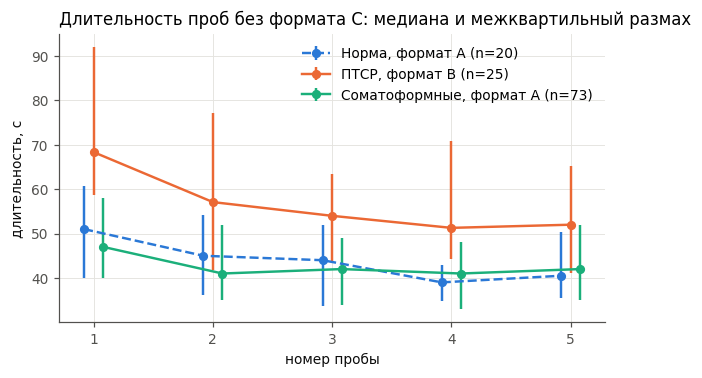

trial                            1      2      3      4      5
group         export_family                                   
Норма         A              51.00  45.00  44.00  39.00  40.50
              B              37.57  33.64  31.72  40.72  35.84
              C              41.00  41.00  41.00  41.00  41.00
ПТСР          B              68.35  57.10  54.00  51.29  52.00
Соматоформные A              47.00  41.00  42.00  41.00  42.00

In [12]:
task = ok[ok["condition"] == "task"]
strata_beh = [(config.GROUP_CONTROL, "A", "--"), (config.GROUP_PTSD, "B", "-"), (config.GROUP_SOMATOFORM, "A", "-")]
fig, ax = plt.subplots(figsize=(6.4, 3.4))
for i, (cohort, fam, style) in enumerate(strata_beh):
    d = task[(task["group"] == cohort) & (task["export_family"] == fam)]
    q = d.groupby("trial")["active_duration_s"].quantile([0.25, 0.5, 0.75]).unstack()
    x = q.index + (i - 1) * 0.08
    ax.errorbar(x, q[0.5], yerr=[q[0.5] - q[0.25], q[0.75] - q[0.5]], color=viz.COHORT_COLORS[cohort], ls=style,
                marker="o", ms=5, capsize=0, lw=1.6, label=f"{cohort}, формат {fam} (n={d['subject_key'].nunique()})")
ax.set_xticks(range(1, 6))
ax.set_xlabel("номер пробы")
ax.set_ylabel("длительность, с")
ax.set_title("Длительность проб без формата C: медиана и межквартильный размах", loc="left")
ax.legend()
plt.show()
task.pivot_table(index=["group", "export_family"], columns="trial", values="active_duration_s", aggfunc="median")

## 1.4 Возраст

Возраст известен только у нормы (из имени папки). По ТЗ ПТСР — мужчины 18–45 лет, соматоформные — 18–45 лет обоих полов.

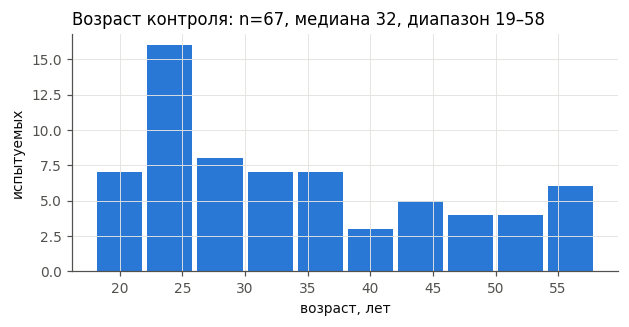

export_family,A,B,C
age,,,
18–29,15,0,16
30–45,3,2,17
46–64,2,0,12


In [13]:
ages = subjects.loc[subjects["group"] == config.GROUP_CONTROL, "age"]
fig, ax = plt.subplots(figsize=(6.4, 2.8))
ax.hist(ages, bins=np.arange(18, 62, 4), color=viz.COHORT_COLORS[config.GROUP_CONTROL], rwidth=0.9)
ax.set_xlabel("возраст, лет")
ax.set_ylabel("испытуемых")
ax.set_title(f"Возраст контроля: n={ages.size}, медиана {ages.median():.0f}, диапазон {ages.min():.0f}–{ages.max():.0f}", loc="left")
plt.show()
controls = subjects[subjects["group"] == config.GROUP_CONTROL]
pd.crosstab(pd.cut(controls["age"], [18, 29, 45, 64], labels=["18–29", "30–45", "46–64"]), controls["export_family"])

## 1.5 Качество: отбраковка окон

Окна 4 с с шагом 2 с; флаги для каждой пары «окно × канал» по общим порогам: плоский сигнал, насыщение, размах > 400 мкВ, выброс дисперсии, выпадение сигнала.

In [14]:
qc = preprocessing.rejection_table(registry, cfg).merge(
    registry[["relpath", "group", "condition", "export_family", "subject_key"]], on="relpath")
qc["frac_good"] = qc["n_good"] / qc["n_windows"].replace(0, np.nan)
flag_cols = ["frac_good", "frac_flat", "frac_rail", "frac_amplitude", "frac_variance", "frac_dropout"]
qc.groupby(["condition", "group"])[flag_cols].mean()

frac_good  frac_flat  frac_rail  frac_amplitude  \
condition group                                                            
rest      Норма               0.98        0.0   0.00e+00        6.34e-03   
          ПТСР                0.87        0.0   3.22e-02        7.81e-02   
          Соматоформные       0.75        0.0   2.22e-03        2.10e-01   
task      Норма               0.94        0.0   0.00e+00        3.79e-02   
          ПТСР                0.86        0.0   3.71e-02        9.27e-02   
          Соматоформные       0.73        0.0   1.33e-03        2.29e-01   

                         frac_variance  frac_dropout  
condition group                                       
rest      Норма                   0.02           0.0  
          ПТСР                    0.10           0.0  
          Соматоформные           0.17           0.0  
task      Норма                   0.05           0.0  
          ПТСР                    0.11           0.0  
          Соматоформные           0.17           0.0

In [15]:
qc.pivot_table(index=["condition", "group"], columns="channel", values="frac_good")[list(config.CHANNELS)]

channel                    O1    T3   Fp1   Fp2    T4    O2
condition group                                            
rest      Норма          0.97  0.97  0.99  0.99  0.99  0.99
          ПТСР           0.88  0.88  0.86  0.90  0.87  0.86
          Соматоформные  0.80  0.64  0.80  0.82  0.63  0.80
task      Норма          0.96  0.91  0.99  0.99  0.84  0.93
          ПТСР           0.90  0.82  0.87  0.91  0.84  0.84
          Соматоформные  0.79  0.61  0.78  0.79  0.61  0.77

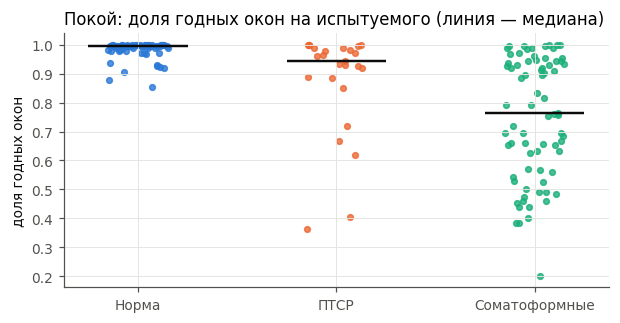

export_family
A    0.95
B    0.98
C    1.00
Name: норма, покой: доля годных окон, dtype: float64

In [16]:
rest_qc = qc[qc["condition"] == "rest"]
per_subject = rest_qc.groupby(["group", "subject_key"])["frac_good"].mean()
fig, ax = plt.subplots(figsize=(6.4, 3.0))
for i, cohort in enumerate(COHORTS):
    v = per_subject.loc[cohort].to_numpy()
    jitter = np.random.default_rng(0).uniform(-0.15, 0.15, v.size)
    ax.scatter(i + jitter, v, s=14, color=viz.COHORT_COLORS[cohort], alpha=0.8)
    ax.hlines(np.median(v), i - 0.25, i + 0.25, color="#0b0b0b", lw=1.6)
ax.set_xticks(range(3), COHORTS)
ax.set_ylabel("доля годных окон")
ax.set_title("Покой: доля годных окон на испытуемого (линия — медиана)", loc="left")
plt.show()
rest_qc[rest_qc["group"] == config.GROUP_CONTROL].groupby("export_family")["frac_good"].mean().rename("норма, покой: доля годных окон")

## 1.6 Примеры сигналов

Первые 10 с покоя после ресэмплинга и ФНЧ 40 Гц; от каждой группы — испытуемый с медианным качеством записи. Ниже — первая проба таблиц и запись с сильными артефактами.

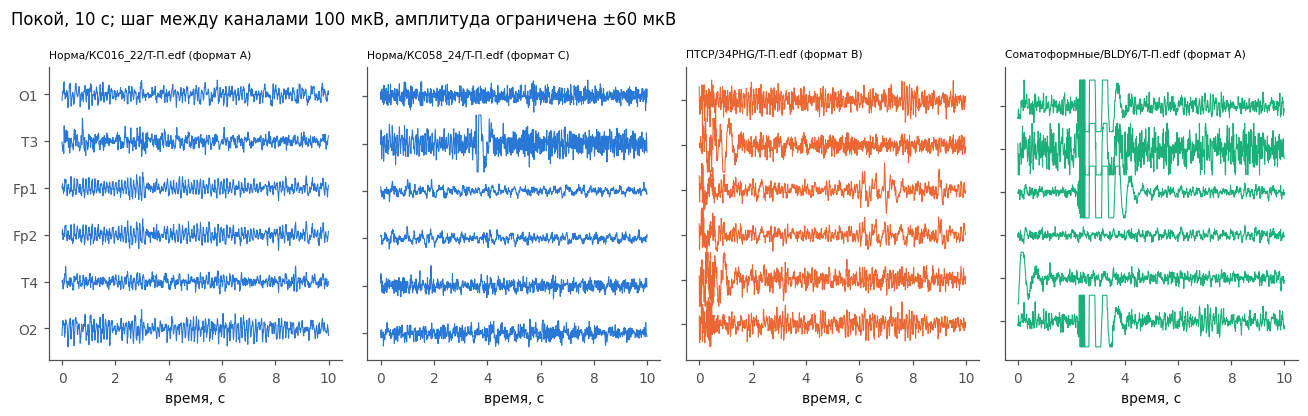

In [17]:
def conditioned(relpath: str) -> np.ndarray:
    rec = dataset.load_record(config.DATA_DIR / relpath)
    x = preprocessing.resample(rec.data, rec.sfreq, cfg.target_sfreq)
    return preprocessing.lowpass(x, cfg.target_sfreq, cfg.lowpass_hz)

def typical_rest(cohort: str, fam: str) -> str:
    rec_quality = rest_qc[(rest_qc["group"] == cohort) & (rest_qc["export_family"] == fam)].groupby("relpath")["frac_good"].mean()
    return (rec_quality - rec_quality.median()).abs().sort_values(kind="stable").index[0]

panels = [(config.GROUP_CONTROL, "A"), (config.GROUP_CONTROL, "C"), (config.GROUP_PTSD, "B"), (config.GROUP_SOMATOFORM, "A")]
fig, axes = plt.subplots(1, 4, figsize=(12, 3.8))
for ax, (cohort, fam) in zip(axes, panels):
    relpath = typical_rest(cohort, fam)
    viz.plot_traces(ax, np.clip(conditioned(relpath)[:, : 10 * 125], -60, 60), cfg.target_sfreq,
                    spacing_uv=100, color=viz.COHORT_COLORS[cohort])
    ax.set_title(f"{relpath} (формат {fam})", loc="left", fontsize=7)
    ax.label_outer()
fig.suptitle("Покой, 10 с; шаг между каналами 100 мкВ, амплитуда ограничена ±60 мкВ", x=0.01, ha="left")
plt.tight_layout()
plt.show()

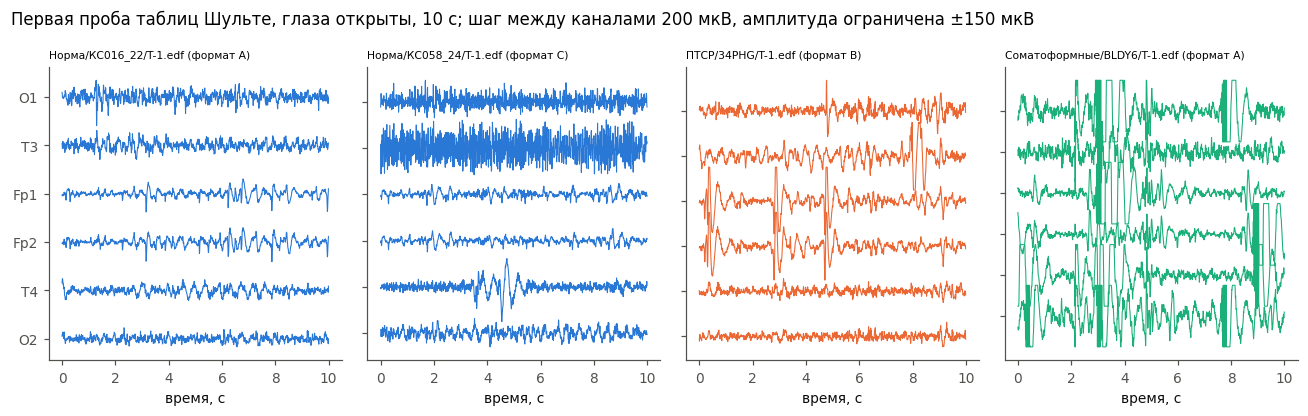

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3.8))
for ax, (cohort, fam) in zip(axes, panels):
    subject_key = typical_rest(cohort, fam).rsplit("/", 1)[0]
    relpath = ok.loc[(ok["subject_key"] == subject_key) & (ok["stem"] == "T-1"), "relpath"].iloc[0]
    viz.plot_traces(ax, np.clip(conditioned(relpath)[:, : 10 * 125], -150, 150), cfg.target_sfreq,
                    spacing_uv=200, color=viz.COHORT_COLORS[cohort])
    ax.set_title(f"{relpath} (формат {fam})", loc="left", fontsize=7)
    ax.label_outer()
fig.suptitle("Первая проба таблиц Шульте, глаза открыты, 10 с; шаг между каналами 200 мкВ, амплитуда ограничена ±150 мкВ",
             x=0.01, ha="left")
plt.tight_layout()
plt.show()

При открытых глазах альфа ослабевает, а лобные и височные каналы ловят моргания, саккады и движения, поэтому в задаче отбраковывается больше окон.

СКО по каналам, мкВ: {'O1': 24, 'T3': 937, 'Fp1': 22, 'Fp2': 24, 'T4': 3296, 'O2': 33}


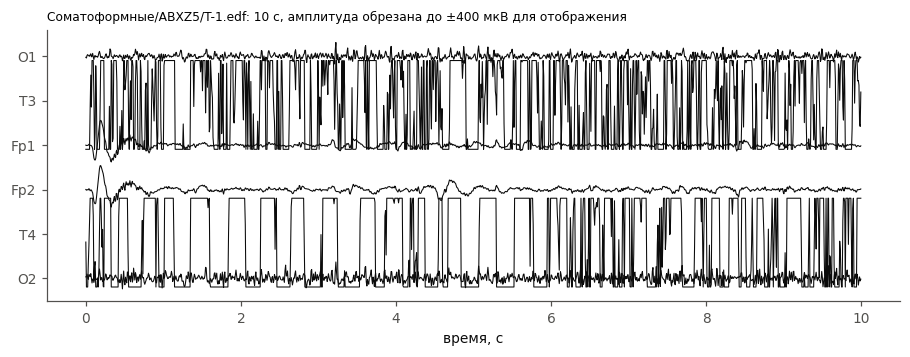

In [19]:
bad = "Соматоформные/ABXZ5/T-1.edf"
x = conditioned(bad)
print("СКО по каналам, мкВ:", {ch: round(float(s)) for ch, s in zip(config.CHANNELS, x.std(axis=1))})
fig, ax = plt.subplots(figsize=(10, 3.2))
viz.plot_traces(ax, np.clip(x[:, : 10 * 125], -400, 400), cfg.target_sfreq, spacing_uv=400)
ax.set_title(f"{bad}: 10 с, амплитуда обрезана до ±400 мкВ для отображения", loc="left", fontsize=8)
plt.show()

## 1.7 Спектр по форматам (без ФНЧ)

Медиана по каналам; пунктир — шум квантования при Δ = 1 мкВ. Выше 40 Гц спектр зависит от формата, поэтому в признаки не входит.

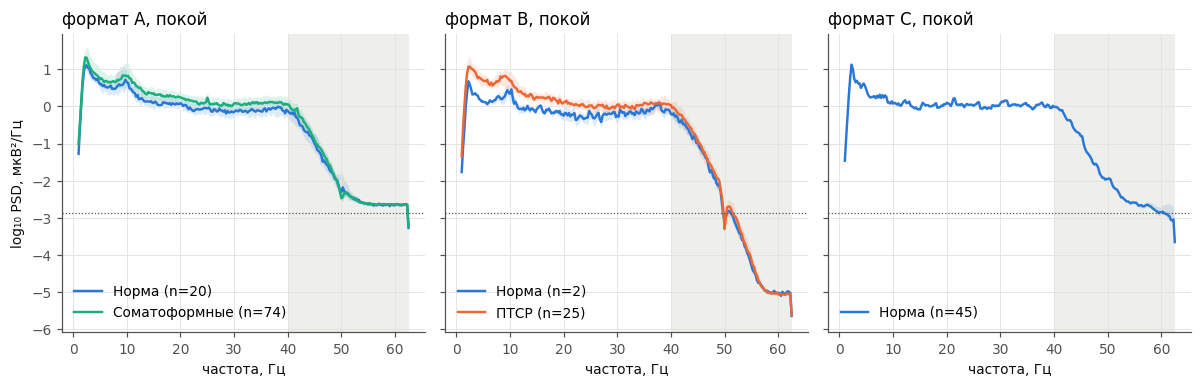

In [20]:
spec_diag = features.compute_spectra(registry, preprocessing.PreprocessingConfig(lowpass_hz=None))
meta = registry.set_index("relpath").loc[list(spec_diag.relpaths)]
per_record = np.nanmedian(spec_diag.spectra, axis=1)
f = spec_diag.freqs
keep = f >= 1.0

fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), sharey=True)
for ax, fam in zip(axes, ["A", "B", "C"]):
    for cohort in COHORTS:
        sel = ((meta["export_family"] == fam) & (meta["group"] == cohort) & (meta["condition"] == "rest")).to_numpy()
        if sel.sum():
            viz.plot_median_spectra(ax, f[keep], per_record[sel][:, keep], cohort, viz.COHORT_COLORS[cohort])
    viz.shade_unused_band(ax, 40.0, 62.5)
    ax.axhline(np.log10(1 / 12 / 62.5), color=viz.TEXT_MUTED, lw=0.8, ls=":")
    ax.set_title(f"формат {fam}, покой", loc="left")
    ax.legend(loc="lower left")
    ax.label_outer()
plt.tight_layout()
plt.show()

## 1.8 Типичные черты ЭЭГ

1. Симметричные каналы коррелируют: общий ушной референт и объёмное проведение.
2. В покое с закрытыми глазами на O1/O2 есть альфа-пик. Выраженность — максимум log₁₀ PSD в 8–13 Гц минус среднее по 5–7 и 14–17 Гц; 0.4 — пик в 2.5 раза выше окружения.

Дополнительно — отношение амплитуды T3 к остальным каналам: T3 ближе всех к референту на левом ухе и ожидается ниже 1.

In [21]:
plaus_all = diagnostics.plausibility_table(registry, cfg).merge(
    registry[["relpath", "group", "export_family", "subject_key", "condition", "subject_id"]], on="relpath")
plaus = plaus_all[plaus_all["condition"] == "rest"]
pair_cols = ["O1-O2", "Fp1-Fp2", "T3-T4"]
keys = ["group", "export_family"]
table = plaus.groupby(keys)[pair_cols + ["alpha_prominence_occ", "t3_rms_ratio"]].median()
table["доля с альфа-пиком > 0.4"] = plaus.groupby(keys)["alpha_prominence_occ"].apply(lambda v: (v > 0.4).mean())
table["записей"] = plaus.groupby(keys).size()
table

O1-O2  Fp1-Fp2  T3-T4  alpha_prominence_occ  \
group         export_family                                                   
Норма         A              5.03e-01     0.84   0.11                  0.91   
              B              6.12e-01     0.80   0.15                  1.15   
              C             -8.97e-04     0.02   0.01                  0.19   
ПТСР          B              6.13e-01     0.89   0.21                  0.83   
Соматоформные A              5.21e-01     0.78   0.16                  0.74   

                             t3_rms_ratio  доля с альфа-пиком > 0.4  записей  
group         export_family                                                   
Норма         A                      0.81                      0.80       20  
              B                      0.81                      0.50        2  
              C                      2.79                      0.00       45  
ПТСР          B                      0.84                      0.88       25  
Соматоформные A                      0.97                      0.81       74

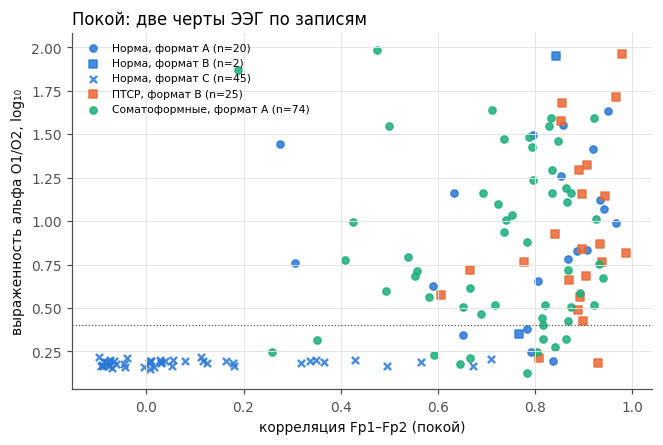

In [22]:
fig, ax = plt.subplots(figsize=(6.8, 4.2))
markers = {"A": "o", "B": "s", "C": "x"}
for cohort in COHORTS:
    for fam, marker in markers.items():
        d = plaus[(plaus["group"] == cohort) & (plaus["export_family"] == fam)]
        if len(d):
            ax.scatter(d["Fp1-Fp2"], d["alpha_prominence_occ"], s=22, marker=marker, color=viz.COHORT_COLORS[cohort],
                       alpha=0.85, label=f"{cohort}, формат {fam} (n={len(d)})")
ax.axhline(0.4, color=viz.TEXT_MUTED, lw=0.8, ls=":")
ax.set_xlabel("корреляция Fp1–Fp2 (покой)")
ax.set_ylabel("выраженность альфа O1/O2, log₁₀")
ax.set_title("Покой: две черты ЭЭГ по записям", loc="left")
ax.legend(fontsize=7, loc="upper left")
plt.show()

Гипотеза «покой записан с открытыми глазами» объяснила бы отсутствие альфы в формате C, но не отсутствие корреляции Fp1–Fp2: при открытых глазах моргания синхронны на обоих лобных каналах. Ниже — те же черты в пробах (глаза открыты).

In [23]:
plaus_all[plaus_all["condition"] == "task"].groupby(keys)[pair_cols + ["t3_rms_ratio"]].median()

O1-O2  Fp1-Fp2     T3-T4  t3_rms_ratio
group         export_family                                           
Норма         A              4.63e-01     0.87  1.35e-01          0.79
              B              4.96e-01     0.92  1.30e-01          1.07
              C             -6.61e-03     0.10  9.25e-04          2.78
ПТСР          B              6.07e-01     0.88  2.37e-01          0.82
Соматоформные A              5.72e-01     0.83  2.06e-01          0.96

In [24]:
low_alpha = plaus[(plaus["group"] == config.GROUP_CONTROL) & (plaus["alpha_prominence_occ"] < 0.3)]
print(f"Норма, покой, выраженность альфа < 0.3: {len(low_alpha)} записей; по форматам:", low_alpha["export_family"].value_counts().to_dict())
low_alpha[low_alpha["export_family"] != "C"][["subject_id", "export_family", "alpha_prominence_occ", "Fp1-Fp2", "O1-O2"]]

Норма, покой, выраженность альфа < 0.3: 47 записей; по форматам: {'C': 45, 'A': 2}


,subject_id,export_family,alpha_prominence_occ,Fp1-Fp2,O1-O2
108,КС054_26,A,0.19,0.84,0.28
390,КС148_23,A,0.25,0.79,0.07


## 1.9 Спектры покоя и задачи по отведениям

Медиана по испытуемым и межквартильный размах; норма форматов A и C — разным стилем линии.

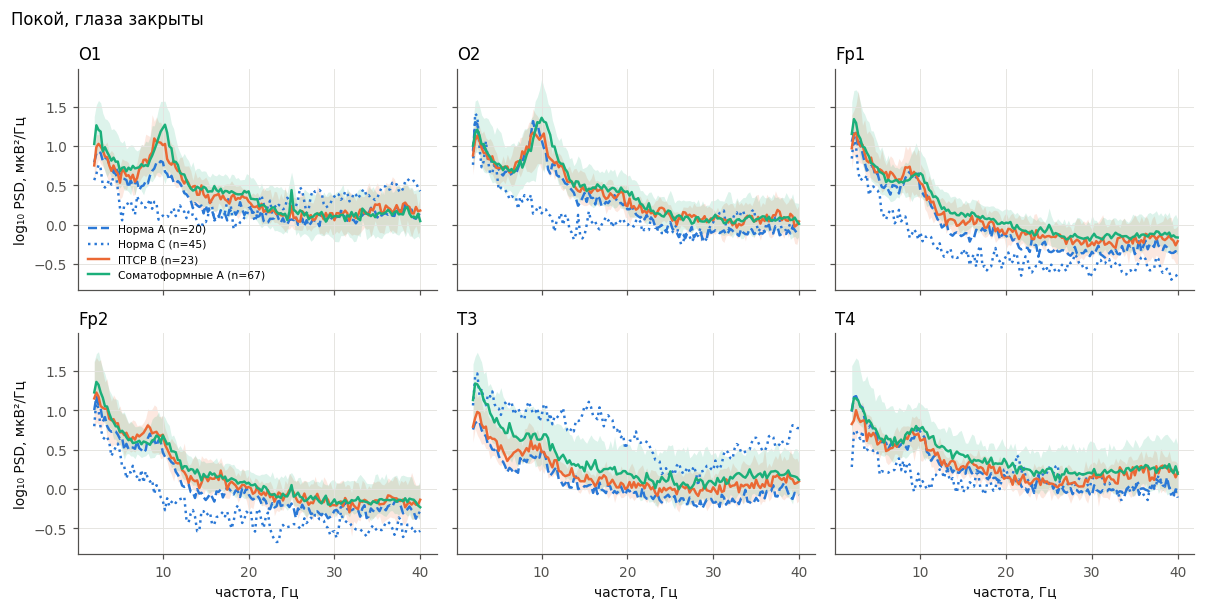

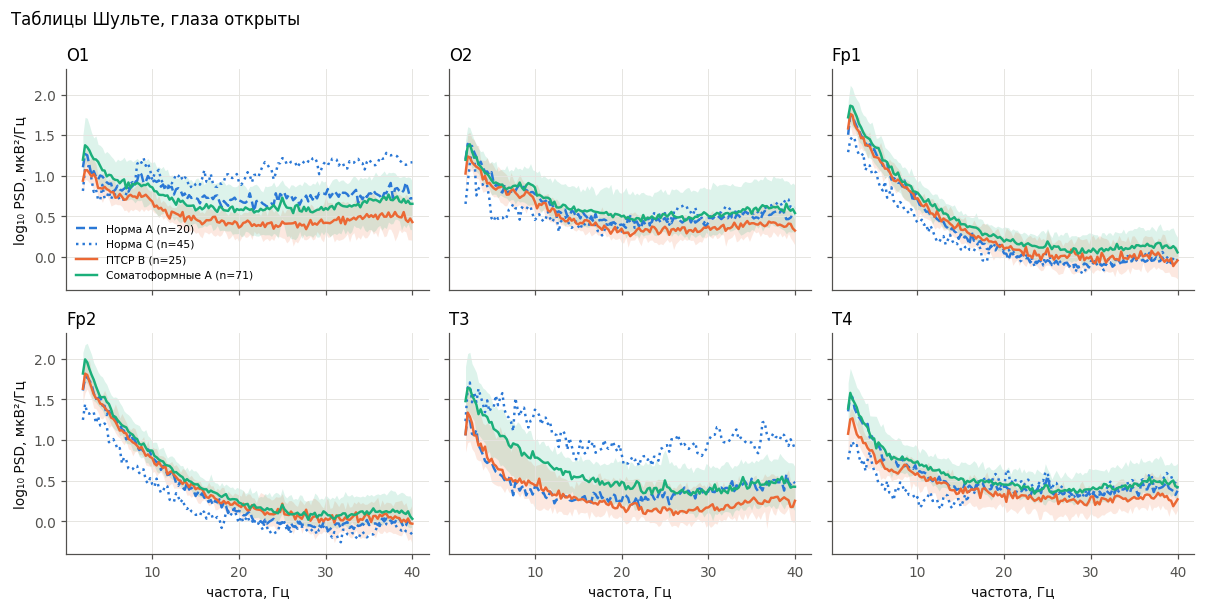

In [25]:
spec = features.compute_spectra(registry, cfg)
meta = registry.set_index("relpath").loc[list(spec.relpaths)].reset_index()
f = spec.freqs
band = (f >= 2.0) & (f <= 40.0)

def subject_spectra(condition: str) -> tuple[np.ndarray, pd.DataFrame]:
    idx = meta.index[(meta["condition"] == condition) & ~meta["condition_conflict"]]
    groups = meta.loc[idx].groupby("subject_key").groups
    keys_ = sorted(groups)
    stacked = np.stack([np.nanmedian(spec.spectra[list(groups[k])], axis=0) for k in keys_])
    return stacked, subjects.loc[keys_, ["group", "export_family"]]

strata = [(config.GROUP_CONTROL, "A", "--"), (config.GROUP_CONTROL, "C", ":"),
          (config.GROUP_PTSD, "B", "-"), (config.GROUP_SOMATOFORM, "A", "-")]
for condition, title in [("rest", "Покой, глаза закрыты"), ("task", "Таблицы Шульте, глаза открыты")]:
    s, info = subject_spectra(condition)
    fig, axes = plt.subplots(2, 3, figsize=(11, 5.6), sharex=True, sharey=True)
    for ax, ch_idx in zip(axes.ravel(), [0, 5, 2, 3, 1, 4]):
        for cohort, fam, style in strata:
            sel = ((info["group"] == cohort) & (info["export_family"] == fam)).to_numpy() & np.isfinite(s[:, ch_idx, band]).all(axis=1)
            viz.plot_median_spectra(ax, f[band], s[sel, ch_idx][:, band], f"{cohort} {fam}", viz.COHORT_COLORS[cohort],
                                    style, band=style == "-")
        ax.set_title(config.CHANNELS[ch_idx], loc="left")
        ax.label_outer()
    axes[0, 0].legend(loc="lower left", fontsize=7)
    fig.suptitle(title, x=0.01, ha="left")
    plt.tight_layout()
    plt.show()

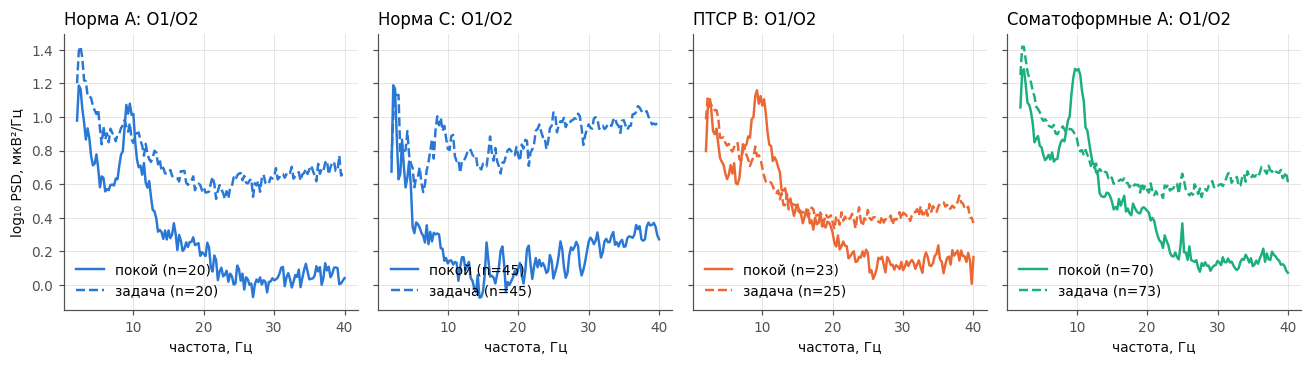

In [26]:
rest_s, rest_info = subject_spectra("rest")
task_s, task_info = subject_spectra("task")
occ = [config.CHANNELS.index("O1"), config.CHANNELS.index("O2")]
fig, axes = plt.subplots(1, 4, figsize=(12, 3.4), sharey=True)
for ax, (cohort, fam, _) in zip(axes, strata):
    for s, info, style, label in [(rest_s, rest_info, "-", "покой"), (task_s, task_info, "--", "задача")]:
        sel = ((info["group"] == cohort) & (info["export_family"] == fam)).to_numpy()
        occipital = np.nanmean(s[sel][:, occ], axis=1)
        viz.plot_median_spectra(ax, f[band], occipital[:, band], label, viz.COHORT_COLORS[cohort], style, band=False)
    ax.set_title(f"{cohort} {fam}: O1/O2", loc="left")
    ax.legend(loc="lower left")
    ax.label_outer()
plt.tight_layout()
plt.show()

## 1.10 Выводы по исходному выпуску

- **Целостность:** 166 ID → 158 независимых групп; 5 пустых файлов; 11 файлов с конфликтом условий.
- **Формат задаёт метку:** все ПТСР — формат B; правило «формат B → ПТСР» даёт AUC 0.985. Высокий AUC сам по себе физиологию не доказывает.
- **Формат C (45 норм) не похож на типичную ЭЭГ:** нет межканальной корреляции и альфы, T3 в 2.8 раза сильнее остальных каналов, длительности проб одинаковы. Причина не установлена.
- **Возраст переплетён с форматом:** 12 из 14 норм старше 45 лет — формат C.
- **Поведение:** первая таблица — ПТСР 68 с, норма A 51 с, соматоформные 47 с.
- **Качество** связано с когортой (годных окон в покое: норма 98%, ПТСР 87%, соматоформные 75%) и в модель не подаётся.

**Гипотезы о признаках (из литературы):**

| Признак | Отведения | Обоснование |
| --- | --- | --- |
| частота и высота альфа-пика | O1 | смещение и ослабление альфы при ПТСР (Kovacevic et al., 2025) |
| наклон спектра | все | апериодический фон (Donoghue et al., 2020) |
| доли мощности тета, альфа, бета | все | классические маркеры, не зависят от усиления |
| лобная асимметрия альфа | Fp1, Fp2 | модель приближения/избегания (Davidson); Fp чувствительны к глазам |
| время решения таблиц | — | оценивается отдельно, с ЭЭГ и без |

Связность и микросостояния не используются: на шести сухих электродах с общим референтом корреляция каналов задаётся референтом (а в формате C её нет вовсе), микросостояниям нужна плотная топография.

## 1.11 Партии 24.09: нормы 65+ и дополнительные нормы

Раздел добавлен позже и тоже описательный. Отсюда два решения протокола 2: правило копий каналов и исключение O2.

In [27]:
ok_all = registry_all[registry_all["status"] == "ok"]
subjects_all["партия"] = np.select(
    [subjects_all["holdout"], ~subjects_all["has_task_files"]], ["нормы 65+", "доп. нормы"], "исходный выпуск")
subjects_all["export_family"] = ok_all.groupby("subject_key")["export_family"].agg(lambda s: "".join(sorted(set(s))))
new_keys = subjects_all.index[subjects_all["партия"] != "исходный выпуск"]
new_reg = registry_all[registry_all["subject_key"].isin(new_keys)].merge(
    subjects_all[["партия"]], left_on="subject_key", right_index=True)
new_ok = new_reg[new_reg["status"] == "ok"]
touched = links["subject_a"].isin(new_keys) | links["subject_b"].isin(new_keys)
status = new_reg["status"].value_counts().to_dict()
print(f"Общих записей с другими испытуемыми: {int(touched.sum())}; файлов по статусу: {status} "
      "(missing — проб, которых у партии нет по протоколу записи)")
print("Имена файлов:", new_ok["file_name"].value_counts().to_dict())
new_ok.groupby(["партия", "stem"]).agg(
    испытуемых=("subject_key", "nunique"), формат=("export_family", lambda v: sorted(set(v))),
    частота_Гц=("sfreq", lambda v: sorted(set(v))), с_нулевым_краем=("edge_constant_s", lambda v: int((v >= 0.1).sum())),
    длительность_мед_с=("active_duration_s", "median"))

Общих записей с другими испытуемыми: 0; файлов по статусу: {'missing': 292, 'ok': 86} (missing — проб, которых у партии нет по протоколу записи)
Имена файлов: {'T-П.edf': 45, 'Т-П.edf': 18, 'Т-1.edf': 18, 'T-1.edf': 5}


испытуемых формат частота_Гц  с_нулевым_краем  \
партия     stem                                                  
доп. нормы T-П           40    [B]    [125.0]               37   
нормы 65+  T-1           23    [B]    [125.0]               22   
           T-П           23    [B]    [125.0]               16   

                 длительность_мед_с  
партия     stem                      
доп. нормы T-П                61.00  
нормы 65+  T-1               113.74  
           T-П                61.01

In [28]:
subjects_all[subjects_all["group"] == config.GROUP_CONTROL].groupby("партия")["age"].describe()[["count", "min", "50%", "max"]]

,count,min,50%,max
партия,,,,
доп. нормы,40.0,17.0,19.5,41.0
исходный выпуск,67.0,19.0,32.0,58.0
нормы 65+,23.0,65.0,68.0,70.0


Обе партии — формат B, как ПТСР, поэтому правило «формат B → ПТСР» слабеет. Но партии отличаются и от исходных записей формата B (ниже).

In [29]:
young_pair = subjects_all[subjects_all["group"].isin([config.GROUP_CONTROL, config.GROUP_PTSD]) & ~subjects_all["holdout"]]
print(f"AUC правила «формат B → ПТСР», все нормы моложе 65: "
      f"{roc_auc_score(young_pair['label'], young_pair['export_family'] == 'B'):.3f} "
      f"(ПТСР {int(young_pair['label'].sum())}, нормы {int((young_pair['label'] == 0).sum())})")

AUC правила «формат B → ПТСР», все нормы моложе 65: 0.804 (ПТСР 25, нормы 107)


**Копии каналов.** Канал, побитово равный другому каналу записи, исключается вместе с парным.

In [30]:
qc_new = preprocessing.rejection_table(new_reg, cfg).merge(new_reg[["relpath", "партия"]], on="relpath")
copies = qc_new[qc_new["frac_copy"] > 0].groupby(["партия", "relpath"])["channel"].agg(", ".join)
print("Записей с копиями каналов:", copies.groupby(level=0).size().to_dict())
copies.to_frame("скопированные каналы")

Записей с копиями каналов: {'доп. нормы': 12, 'нормы 65+': 2}


скопированные каналы
партия     relpath                                     
доп. нормы Норма/КС205_22/T-П.edf                T3, T4
           Норма/КС217_18/T-П.edf                T3, T4
           Норма/КС224_18/T-П.edf                T3, O2
           Норма/КС225_19/T-П.edf                T3, O2
           Норма/КС227_20/T-П.edf            T3, T4, O2
           Норма/КС229_40/T-П.edf                T3, T4
           Норма/КС230_21/T-П.edf                T3, O2
           Норма/КС233_20/T-П.edf                T3, O2
           Норма/КС234_19/T-П.edf            T3, T4, O2
           Норма/КС238м_18/T-П.edf               T3, O2
           Норма/КС239м_19/T-П.edf               T3, O2
           Норма/КС240м_20/T-П.edf               T3, O2
нормы 65+  Норма/A003_68/T-1.edf                 T3, O2
           Норма/A003_68/T-П.edf                 T3, O2

**Черты ЭЭГ по партиям** — те же проверки плюс корреляция O2–Fp2.

In [31]:
plaus_new = diagnostics.plausibility_table(new_reg[new_reg["stem"] == config.REST_STEM], cfg).merge(
    new_reg[["relpath", "партия"]], on="relpath")
reference = plaus.assign(партия=plaus["group"] + " " + plaus["export_family"])
both = pd.concat([reference, plaus_new], ignore_index=True)
cols = ["O1-O2", "Fp1-Fp2", "O2-Fp2", "alpha_prominence_occ", "t3_rms_ratio"]
table_new = both.groupby("партия")[cols].median()
table_new["доля O2–Fp2 > 0.6"] = both.groupby("партия")["O2-Fp2"].apply(lambda v: (v > 0.6).mean())
table_new["доля с альфа-пиком > 0.4"] = both.groupby("партия")["alpha_prominence_occ"].apply(lambda v: (v > 0.4).mean())
table_new["записей"] = both.groupby("партия").size()
table_new

,O1-O2,Fp1-Fp2,O2-Fp2,alpha_prominence_occ,t3_rms_ratio,доля O2–Fp2 > 0.6,доля с альфа-пиком > 0.4,записей
партия,,,,,,,,
Норма A,5.03e-01,0.84,1.51e-01,0.91,0.81,0.00,0.80,20
Норма B,6.12e-01,0.80,6.63e-02,1.15,0.81,0.00,0.50,2
Норма C,-8.97e-04,0.02,-2.26e-03,0.19,2.79,0.00,0.00,45
ПТСР B,6.13e-01,0.89,1.36e-01,0.83,0.84,0.04,0.88,25
Соматоформные A,5.21e-01,0.78,1.57e-01,0.74,0.97,0.01,0.81,74
доп. нормы,2.07e-02,0.80,8.35e-01,0.70,1.00,0.68,0.82,40
нормы 65+,5.08e-01,0.81,4.11e-01,0.23,1.00,0.26,0.17,23


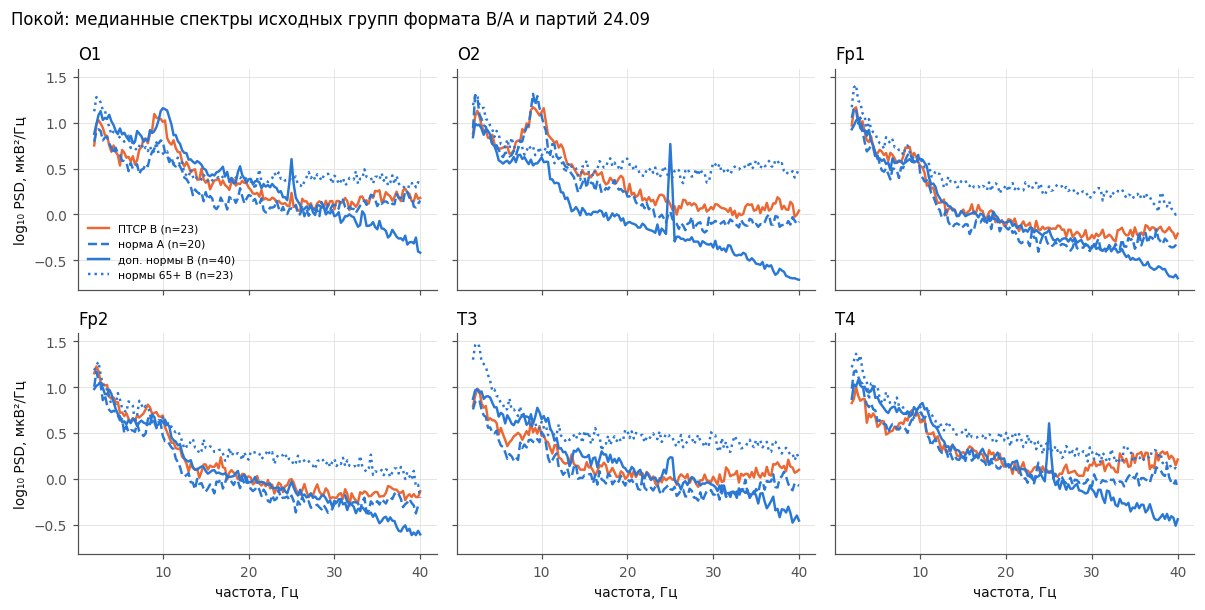

In [32]:
spec_new = features.compute_spectra(new_reg[new_reg["stem"] == config.REST_STEM], cfg)
new_batch = new_reg.set_index("relpath").loc[list(spec_new.relpaths), "партия"].to_numpy()
rest_meta = meta[(meta["condition"] == "rest") & ~meta["condition_conflict"]]
curves = [
    ("ПТСР B", spec.spectra[rest_meta.index[rest_meta["group"] == config.GROUP_PTSD]], viz.COHORT_COLORS[config.GROUP_PTSD], "-"),
    ("норма A", spec.spectra[rest_meta.index[(rest_meta["group"] == config.GROUP_CONTROL) & (rest_meta["export_family"] == "A")]],
     viz.COHORT_COLORS[config.GROUP_CONTROL], "--"),
    ("доп. нормы B", spec_new.spectra[new_batch == "доп. нормы"], viz.COHORT_COLORS[config.GROUP_CONTROL], "-"),
    ("нормы 65+ B", spec_new.spectra[new_batch == "нормы 65+"], viz.COHORT_COLORS[config.GROUP_CONTROL], ":"),
]
fig, axes = plt.subplots(2, 3, figsize=(11, 5.6), sharex=True, sharey=True)
for ax, ch_idx in zip(axes.ravel(), [0, 5, 2, 3, 1, 4]):
    for label, s, color, style in curves:
        s = s[:, ch_idx][:, band]
        viz.plot_median_spectra(ax, f[band], s[np.isfinite(s).all(axis=1)], label, color, style, band=False)
    ax.set_title(config.CHANNELS[ch_idx], loc="left")
    ax.label_outer()
axes[0, 0].legend(loc="lower left", fontsize=7)
fig.suptitle("Покой: медианные спектры исходных групп формата B/A и партий 24.09", x=0.01, ha="left")
plt.tight_layout()
plt.show()

**Время решения первой таблицы** (без формата C).

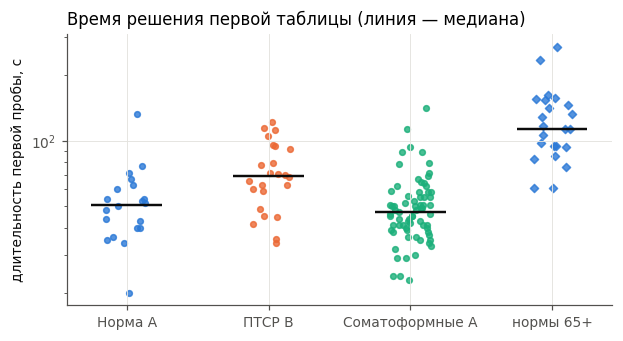

,count,25%,50%,75%
страта,,,,
Норма A,20.0,40.00,51.00,60.75
ПТСР B,24.0,56.20,69.06,92.64
Соматоформные A,71.0,39.50,47.00,57.00
нормы 65+,23.0,94.12,113.74,150.25


In [33]:
trial1 = ok_all[(ok_all["stem"] == "T-1") & (ok_all["export_family"] != "C") & ~ok_all["condition_conflict"]].merge(
    subjects_all[["партия"]], left_on="subject_key", right_index=True)
trial1 = trial1.assign(страта=np.where(trial1["партия"] == "нормы 65+", "нормы 65+", trial1["group"] + " " + trial1["export_family"]))
order = ["Норма A", "ПТСР B", "Соматоформные A", "нормы 65+"]
colors = [viz.COHORT_COLORS[config.GROUP_CONTROL], viz.COHORT_COLORS[config.GROUP_PTSD],
          viz.COHORT_COLORS[config.GROUP_SOMATOFORM], viz.COHORT_COLORS[config.GROUP_CONTROL]]
fig, ax = plt.subplots(figsize=(6.4, 3.2))
rng = np.random.default_rng(0)
for i, (name, color) in enumerate(zip(order, colors)):
    v = trial1.loc[trial1["страта"] == name, "active_duration_s"].to_numpy()
    ax.scatter(i + rng.uniform(-0.15, 0.15, v.size), v, s=14, color=color, alpha=0.8,
               marker="o" if name != "нормы 65+" else "D")
    ax.hlines(np.median(v), i - 0.25, i + 0.25, color="#0b0b0b", lw=1.6)
ax.set_xticks(range(len(order)), order)
ax.set_yscale("log")
ax.set_ylabel("длительность первой пробы, с")
ax.set_title("Время решения первой таблицы (линия — медиана)", loc="left")
plt.show()
trial1.groupby("страта")["active_duration_s"].describe()[["count", "25%", "50%", "75%"]].reindex(order)

### Выводы по партиям 24.09

- **Нормы 65+:** межканальные корреляции типичны, но выраженный альфа-пик лишь у 17% записей — возрастное ослабление альфы. Первую таблицу решают дольше всех (114 с против 69 с у ПТСР): время решения само по себе приняло бы их за ПТСР.
- **Дополнительные нормы:** в 12 из 40 файлов скопированы каналы; O2 ведёт себя как лобный канал (корреляция с Fp2 0.84); узкий пик 25 Гц и крутой спад к 40 Гц — признаки другой партии регистрации.
- **Следствия:** правило «формат B → ПТСР» даёт уже 0.80, но различение ПТСР и новой партии может отражать партию, а не диагноз. Это проверяется в ноутбуке 4.